# 05 · Time Delay Embedding + Mapper — BabyFaceValidation

Este notebook extiende el análisis topológico descriptivo con una lectura temporal explícita. El objetivo es transformar las trayectorias afectivas de cada infante mediante **Time Delay Embedding (TDE)** y después construir un grafo tipo **Mapper** para identificar regiones de comportamiento dinámico: adaptación, transición, rechazo o alta variabilidad afectiva.

La unidad de análisis ya no es solamente una observación aislada, sino una ventana de estados consecutivos por `id`.

## 1. Carga de librerías y configuración

Se mantiene la misma lógica de los notebooks previos: limpieza reproducible, salidas en una carpeta dedicada y uso de librerías científicas estándar.

In [1]:
from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display, Markdown
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

DATA_CANDIDATES = [
    Path("DataFrameBabyFaceValidacion.xlsx"),
    Path("extracted/DataFrameBabyFaceValidacion.xlsx"),
    Path("../extracted/DataFrameBabyFaceValidacion.xlsx"),
    Path("/mnt/data/DataFrameBabyFaceValidacion.xlsx"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró DataFrameBabyFaceValidacion.xlsx.")

OUTPUT_DIR = Path("babyface_tde_mapper_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

print(f"Base de datos: {DATA_PATH.resolve()}")
print(f"Carpeta de salidas: {OUTPUT_DIR.resolve()}")

Base de datos: /home/jorge/Projects/topo/babyFace/DataFrameBabyFaceValidacion.xlsx
Carpeta de salidas: /home/jorge/Projects/topo/babyFace/babyface_tde_mapper_outputs


## 2. Limpieza base y orden temporal

El TDE requiere una secuencia ordenada. Para eso se extrae el número de `dia` y una fase textual cuando aparece algo como `2E` o `4P`. Las fases se usan solo para ordenar exposiciones dentro del mismo día.

In [2]:
MISSING_TOKENS = {'', '-', 'NA', 'NA ', 'N/A', 'nan', 'NaN', 'FIT_FAILED', 'FIT FAILED', 'FIND_FAILED', 'FIND FAILED', 'S/I', None}
BEHAVIOR_COLS = ['rechaza', 'llora', 'toca', 'prueba', 'consume']
TIME_COLS = ['t_total', 't_prueba1', 't_prueba2']
AFFECT_COLS = []


def normalize_missing_value(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str) and x.strip() in MISSING_TOKENS:
        return np.nan
    return x


def parse_day_num(x):
    x = normalize_missing_value(x)
    if pd.isna(x):
        return np.nan
    m = re.search(r"\d+", str(x))
    return float(m.group(0)) if m else np.nan


def parse_day_phase(x):
    x = normalize_missing_value(x)
    if pd.isna(x):
        return "base"
    s = str(x).strip().upper()
    m = re.search(r"[A-Z]+", s)
    return m.group(0) if m else "base"


def parse_time_to_seconds(x):
    x = normalize_missing_value(x)
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        value = float(x)
        return value / 1000 if value > 1000 else value
    s = str(x).strip().replace(',', '.')
    if ':' in s:
        try:
            parts = [float(p) for p in s.split(':')]
            if len(parts) == 3:
                return parts[0] * 3600 + parts[1] * 60 + parts[2]
            if len(parts) == 2:
                return parts[0] * 60 + parts[1]
        except Exception:
            return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

raw = pd.read_excel(DATA_PATH)
AFFECT_COLS = [c for c in raw.columns if c.startswith('valence') or c.startswith('arousal')]

df = raw.copy()
df['row_original'] = np.arange(len(df))
df['dia_num'] = df['dia'].map(parse_day_num)
df['fase_dia'] = df['dia'].map(parse_day_phase)
phase_order = {'E': 0, 'P': 1, 'BASE': 2, 'base': 2}
df['fase_orden'] = df['fase_dia'].map(lambda x: phase_order.get(str(x).upper(), 2))

for col in AFFECT_COLS + BEHAVIOR_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].map(normalize_missing_value), errors='coerce')
for col in TIME_COLS:
    if col in df.columns:
        df[col] = df[col].map(parse_time_to_seconds)

df = df.sort_values(['id', 'dia_num', 'fase_orden', 'row_original']).reset_index(drop=True)
df['orden_exposicion'] = df.groupby('id').cumcount() + 1

display(df[['id','dia','dia_num','fase_dia','orden_exposicion','valence_final','arousal_final','consume','rechaza']].head(15))
print(f"Dimensiones limpias: {df.shape[0]} filas x {df.shape[1]} columnas")

,id,dia,dia_num,fase_dia,orden_exposicion,valence_final,arousal_final,consume,rechaza
0,ID1,1,1.0000,base,1,0.3324,0.7401,1.0000,0.0000
1,ID1,2,2.0000,base,2,0.0884,0.8984,1.0000,0.0000
2,ID1,3,3.0000,base,3,0.0809,0.7748,1.0000,0.0000
3,ID1,4,4.0000,base,4,0.1145,0.6569,1.0000,0.0000
4,ID1,5,5.0000,base,5,0.0696,0.7081,0.0000,0.0000
5,ID1,6,6.0000,base,6,NaN,NaN,1.0000,0.0000
6,ID1,7,7.0000,base,7,0.3709,0.7599,1.0000,0.0000
7,ID1,8,8.0000,base,8,NaN,NaN,1.0000,0.0000
8,ID1,9,9.0000,base,9,NaN,NaN,0.0000,0.0000
9,ID1,10,10.0000,base,10,NaN,NaN,1.0000,0.0000


Dimensiones limpias: 366 filas x 32 columnas


## 3. Cobertura temporal para TDE

Antes de crear embeddings se revisa cuántas exposiciones útiles tiene cada infante. Para un embedding con dimensión `m=3` y retardo `tau=1`, cada `id` necesita al menos tres estados temporales completos.

,id,n_registros,dia_min,dia_max,valence_obs,arousal_obs,consume_rate,rechaza_rate,registros_va_completos,apto_tde_m3_tau1
0,ID1,15,1.0000,15.0000,11,11,0.8670,0.0000,11,True
11,ID2,6,1.0000,6.0000,4,4,0.8330,0.3330,4,True
13,ID3,19,1.0000,17.0000,17,17,0.4740,0.3160,17,True
14,ID4,18,1.0000,17.0000,18,18,0.7220,0.6110,18,True
15,ID5,16,1.0000,16.0000,16,16,0.9380,0.2500,16,True
16,ID6,9,1.0000,9.0000,8,8,0.4440,0.6670,8,True
17,ID7,35,2.0000,21.0000,31,31,0.2290,0.8570,31,True
18,ID8,26,1.0000,20.0000,25,25,0.5380,0.5000,25,True
19,ID9,15,1.0000,15.0000,14,14,1.0000,0.0000,14,True
1,ID10,24,1.0000,16.0000,22,22,0.0870,0.9130,22,True


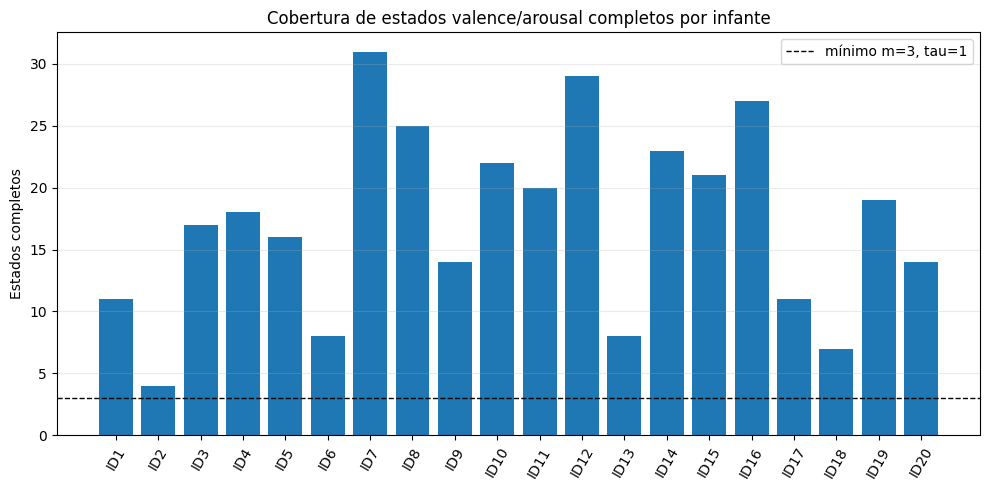

In [3]:
signal_cols = ['valence_final', 'arousal_final']
context_cols = ['consume', 'rechaza', 'prueba', 'llora', 'toca']

coverage = df.groupby('id').agg(
    n_registros=('orden_exposicion','count'),
    dia_min=('dia_num','min'),
    dia_max=('dia_num','max'),
    valence_obs=('valence_final','count'),
    arousal_obs=('arousal_final','count'),
    consume_rate=('consume','mean'),
    rechaza_rate=('rechaza','mean')
).reset_index()
coverage['registros_va_completos'] = df.dropna(subset=signal_cols).groupby('id').size().reindex(coverage['id']).fillna(0).astype(int).values
coverage['apto_tde_m3_tau1'] = coverage['registros_va_completos'] >= 3
coverage = coverage.sort_values('id', key=lambda s: s.str.replace('ID','').astype(int))
coverage.round(3).to_csv(OUTPUT_DIR / '05_cobertura_tde_por_id.csv', index=False)
display(coverage.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(coverage['id'], coverage['registros_va_completos'])
ax.axhline(3, color='black', linewidth=1, linestyle='--', label='mínimo m=3, tau=1')
ax.set_title('Cobertura de estados valence/arousal completos por infante')
ax.set_ylabel('Estados completos')
ax.tick_params(axis='x', rotation=60)
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_cobertura_tde_por_id.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Construcción del Time Delay Embedding

Se usa la trayectoria bivariada `(valence_final, arousal_final)` por infante. Para cada tiempo `t` se construye el vector:

`[x_t, x_{t-1}, x_{t-2}]`, donde cada `x` contiene valencia y arousal.

Con `m=3` y `tau=1`, cada punto embebido resume tres exposiciones consecutivas.

In [4]:
def interpolate_group(g, cols):
    g = g.sort_values('orden_exposicion').copy()
    for col in cols:
        g[col] = g[col].interpolate(method='linear', limit_direction='both')
        if g[col].isna().any():
            g[col] = g[col].fillna(df[col].median())
    return g


def build_delay_embedding(data, signal_cols, m=3, tau=1):
    rows = []
    for id_value, g in data.groupby('id'):
        g = interpolate_group(g, signal_cols + context_cols)
        g = g.dropna(subset=signal_cols).sort_values('orden_exposicion').reset_index(drop=True)
        if len(g) < (m - 1) * tau + 1:
            continue
        values = g[signal_cols].to_numpy(float)
        for pos in range((m - 1) * tau, len(g)):
            pieces = []
            for lag in range(m):
                pieces.extend(values[pos - lag * tau].tolist())
            row = {
                'id': id_value,
                'posicion_local': pos + 1,
                'dia': g.loc[pos, 'dia'],
                'dia_num': g.loc[pos, 'dia_num'],
                'fase_dia': g.loc[pos, 'fase_dia'],
                'orden_exposicion': g.loc[pos, 'orden_exposicion'],
                'consume': g.loc[pos, 'consume'],
                'rechaza': g.loc[pos, 'rechaza'],
                'prueba': g.loc[pos, 'prueba'],
                'llora': g.loc[pos, 'llora'],
                'toca': g.loc[pos, 'toca'],
            }
            for j, value in enumerate(pieces):
                signal = signal_cols[j % len(signal_cols)]
                lag = j // len(signal_cols)
                row[f'{signal}_lag{lag}'] = value
            row['delta_valence_ventana'] = values[pos, 0] - values[pos - (m - 1) * tau, 0]
            row['delta_arousal_ventana'] = values[pos, 1] - values[pos - (m - 1) * tau, 1]
            rows.append(row)
    return pd.DataFrame(rows)

M = 3
TAU = 1
emb = build_delay_embedding(df, signal_cols, m=M, tau=TAU)
feature_cols = [c for c in emb.columns if '_lag' in c]
X = emb[feature_cols].to_numpy(float)
X_scaled = StandardScaler().fit_transform(X)

print(f"Parámetros TDE: m={M}, tau={TAU}")
print(f"Puntos embebidos: {emb.shape[0]}")
print(f"Dimensión del embedding: {len(feature_cols)}")
display(emb.head())
emb.to_csv(OUTPUT_DIR / '05_time_delay_embedding_m3_tau1.csv', index=False)

Parámetros TDE: m=3, tau=1
Puntos embebidos: 326
Dimensión del embedding: 6


,id,posicion_local,dia,dia_num,fase_dia,orden_exposicion,consume,rechaza,prueba,llora,toca,valence_final_lag0,arousal_final_lag0,valence_final_lag1,arousal_final_lag1,valence_final_lag2,arousal_final_lag2,delta_valence_ventana,delta_arousal_ventana
0,ID1,3,3,3.0000,base,3,1.0000,0.0000,1.0000,0.0000,0.0000,0.0809,0.7748,0.0884,0.8984,0.3324,0.7401,-0.2515,0.0346
1,ID1,4,4,4.0000,base,4,1.0000,0.0000,1.0000,0.0000,0.0000,0.1145,0.6569,0.0809,0.7748,0.0884,0.8984,0.0261,-0.2415
2,ID1,5,5,5.0000,base,5,0.0000,0.0000,1.0000,0.0000,0.0000,0.0696,0.7081,0.1145,0.6569,0.0809,0.7748,-0.0113,-0.0666
3,ID1,6,6,6.0000,base,6,1.0000,0.0000,1.0000,0.0000,0.0000,0.2202,0.7340,0.0696,0.7081,0.1145,0.6569,0.1058,0.0772
4,ID1,7,7,7.0000,base,7,1.0000,0.0000,1.0000,0.0000,0.0000,0.3709,0.7599,0.2202,0.7340,0.0696,0.7081,0.3012,0.0518


## 5. Proyección del embedding

Para visualizar el espacio embebido se usa PCA. Esta proyección no reemplaza el TDE; solo sirve como lente y como apoyo visual para interpretar trayectorias dinámicas.

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.3657,0.3657
1,PC2,0.2062,0.5719


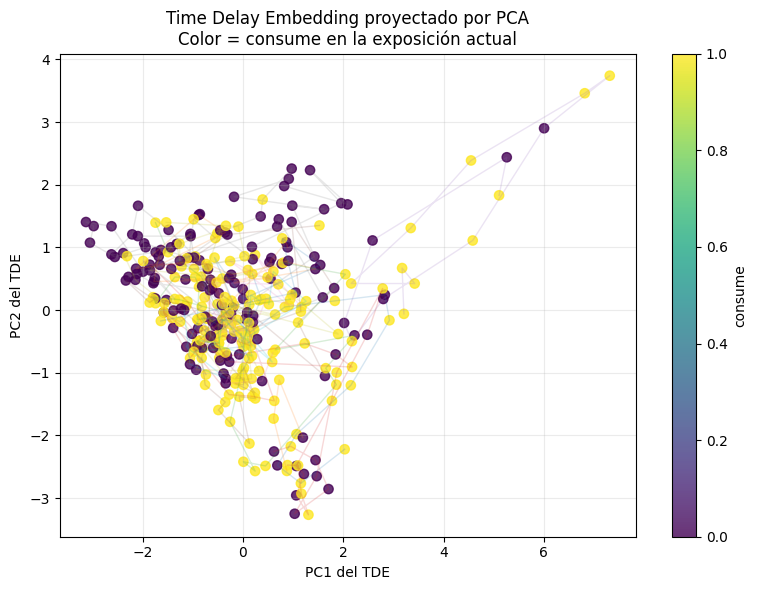

In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
emb['PC1'] = coords[:, 0]
emb['PC2'] = coords[:, 1]

pca_summary = pd.DataFrame({
    'componente': ['PC1', 'PC2'],
    'varianza_explicada': pca.explained_variance_ratio_,
    'varianza_acumulada': np.cumsum(pca.explained_variance_ratio_)
})
pca_summary.to_csv(OUTPUT_DIR / '05_pca_embedding_summary.csv', index=False)
display(pca_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(emb['PC1'], emb['PC2'], c=emb['consume'], cmap='viridis', s=45, alpha=0.8)
for id_value, sub in emb.groupby('id'):
    ax.plot(sub['PC1'], sub['PC2'], alpha=0.18, linewidth=1)
ax.set_xlabel('PC1 del TDE')
ax.set_ylabel('PC2 del TDE')
ax.set_title('Time Delay Embedding proyectado por PCA\nColor = consume en la exposición actual')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('consume')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_tde_pca_consume.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Grafo Mapper sobre el TDE

Mapper se construye con:

- **Datos base:** puntos del TDE estandarizados.
- **Lente:** `PC1`, porque resume la dirección principal de variación dinámica.
- **Cubierta:** intervalos traslapados sobre la lente.
- **Clustering local:** DBSCAN dentro de cada intervalo.
- **Aristas:** dos nodos se conectan si comparten al menos una observación.

In [6]:
def build_mapper_graph(X_scaled, lens, meta, n_intervals=8, overlap=0.35, min_interval_points=5, min_cluster_size=3):
    lo, hi = float(np.min(lens)), float(np.max(lens))
    width = (hi - lo) / (n_intervals - (n_intervals - 1) * overlap)
    step = width * (1 - overlap)
    intervals = [(lo + i * step, lo + i * step + width) for i in range(n_intervals)]

    node_members = []
    node_rows = []
    node_id = 0
    for interval_idx, (a, b) in enumerate(intervals):
        local_idx = np.where((lens >= a) & (lens <= b))[0]
        if len(local_idx) < min_interval_points:
            continue
        Xi = X_scaled[local_idx]
        k = min(5, len(local_idx))
        nn = NearestNeighbors(n_neighbors=k).fit(Xi)
        dists, _ = nn.kneighbors(Xi)
        eps = max(float(np.median(dists[:, -1])), 0.55)
        labels = DBSCAN(eps=eps, min_samples=min(3, len(local_idx))).fit_predict(Xi)
        for lab in sorted(set(labels)):
            if lab == -1:
                continue
            members_pos = local_idx[labels == lab]
            if len(members_pos) < min_cluster_size:
                continue
            members = set(meta.index[members_pos])
            sub = meta.iloc[members_pos]
            node_members.append(members)
            node_rows.append({
                'node': node_id,
                'intervalo': interval_idx,
                'lens_min': a,
                'lens_max': b,
                'n': len(sub),
                'ids_n': sub['id'].nunique(),
                'consume_rate': sub['consume'].mean(),
                'rechaza_rate': sub['rechaza'].mean(),
                'prueba_rate': sub['prueba'].mean(),
                'llora_rate': sub['llora'].mean(),
                'delta_valence_media': sub['delta_valence_ventana'].mean(),
                'delta_arousal_media': sub['delta_arousal_ventana'].mean(),
                'pc1_media': sub['PC1'].mean(),
                'pc2_media': sub['PC2'].mean(),
                'ids': ', '.join(sorted(sub['id'].unique(), key=lambda x: int(x.replace('ID','')))),
            })
            node_id += 1

    G = nx.Graph()
    for row in node_rows:
        G.add_node(row['node'])
    for i in range(len(node_members)):
        for j in range(i + 1, len(node_members)):
            shared = node_members[i].intersection(node_members[j])
            if shared:
                G.add_edge(i, j, weight=len(shared))
    return G, pd.DataFrame(node_rows), node_members, intervals

G, node_table, node_members, intervals = build_mapper_graph(X_scaled, emb['PC1'].to_numpy(), emb.reset_index(drop=True), n_intervals=8, overlap=0.35)
node_table.round(3).to_csv(OUTPUT_DIR / '05_mapper_node_table.csv', index=False)

mapper_summary = pd.DataFrame({
    'métrica': ['nodos', 'aristas', 'componentes_conectadas', 'n_puntos_tde', 'intervalos', 'overlap'],
    'valor': [G.number_of_nodes(), G.number_of_edges(), nx.number_connected_components(G) if G.number_of_nodes() else 0, len(emb), 8, 0.35]
})
mapper_summary.to_csv(OUTPUT_DIR / '05_mapper_summary.csv', index=False)
display(mapper_summary)
display(node_table.round(3))

,métrica,valor
0,nodos,12.0000
1,aristas,10.0000
2,componentes_conectadas,2.0000
3,n_puntos_tde,326.0000
4,intervalos,8.0000
5,overlap,0.3500


,node,intervalo,lens_min,lens_max,n,ids_n,consume_rate,rechaza_rate,prueba_rate,llora_rate,delta_valence_media,delta_arousal_media,pc1_media,pc2_media,ids
0,0,0,-3.1300,-1.2480,49,9,0.2860,0.7140,0.4080,0.0000,0.0010,-0.0040,-1.8920,0.6860,"ID7, ID8, ID10, ID11, ID12, ID14, ID16, ID17, ..."
1,1,1,-1.9070,-0.0250,129,17,0.6050,0.3800,0.6980,0.0000,0.0010,0.0210,-0.8270,-0.0370,"ID1, ID5, ID6, ID7, ID8, ID9, ID10, ID11, ID12..."
2,2,1,-1.9070,-0.0250,3,3,0.3330,0.6670,0.3330,0.0000,-0.0330,0.2430,-0.2460,-1.0240,"ID6, ID12, ID17"
3,3,2,-0.6840,1.1980,117,19,0.6750,0.3160,0.7780,0.0560,0.0070,-0.0010,0.0020,-0.6300,"ID1, ID2, ID3, ID5, ID6, ID7, ID8, ID9, ID10, ..."
4,4,2,-0.6840,1.1980,3,2,0.0000,1.0000,0.0000,0.3330,-0.0830,-0.1250,0.0940,1.7250,"ID7, ID8"
5,5,2,-0.6840,1.1980,3,3,0.6670,0.3330,1.0000,0.3330,0.0270,-0.0740,0.5510,0.7580,"ID9, ID10, ID19"
6,6,3,0.5390,2.4210,57,15,0.5440,0.4040,0.7540,0.1140,-0.0510,-0.0200,1.1280,-0.5960,"ID1, ID2, ID3, ID4, ID6, ID7, ID8, ID9, ID10, ..."
7,7,3,0.5390,2.4210,6,6,0.8330,0.1670,0.8330,0.1670,0.2240,0.2570,2.0810,-0.7320,"ID1, ID3, ID4, ID8, ID12, ID20"
8,8,3,0.5390,2.4210,3,3,0.0000,1.0000,0.0000,0.0000,-0.4630,-0.4010,1.2160,0.9680,"ID7, ID16, ID19"
9,9,4,1.7620,3.6440,24,7,0.7080,0.3750,0.8750,0.1670,-0.0190,0.0150,2.3720,-0.1930,"ID1, ID3, ID4, ID8, ID12, ID14, ID20"


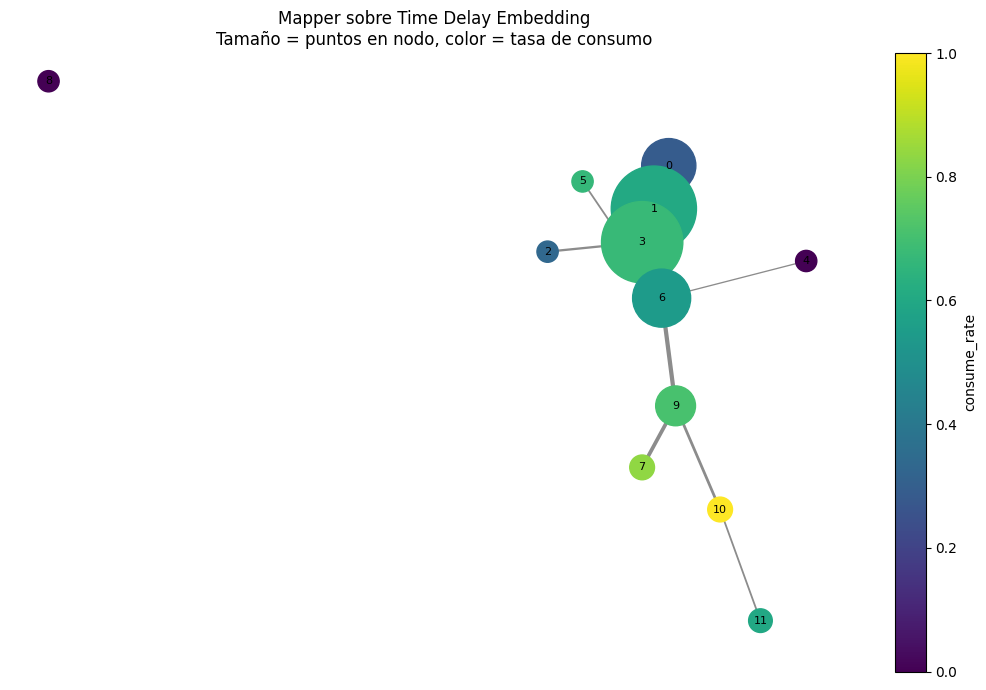

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
if G.number_of_nodes() > 0:
    pos = nx.spring_layout(G, seed=42, weight='weight')
    sizes = [150 + 28 * node_table.loc[node_table['node'] == n, 'n'].iloc[0] for n in G.nodes]
    colors = [node_table.loc[node_table['node'] == n, 'consume_rate'].iloc[0] for n in G.nodes]
    widths = [0.6 + 0.35 * G[u][v].get('weight', 1) for u, v in G.edges]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.45, ax=ax)
    nodes = nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, cmap='viridis', vmin=0, vmax=1, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    cbar = fig.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('consume_rate')
ax.set_title('Mapper sobre Time Delay Embedding\nTamaño = puntos en nodo, color = tasa de consumo')
ax.axis('off')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_mapper_tde_graph.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Interpretación de regiones dinámicas

Para convertir los nodos de Mapper en hallazgos, se etiquetan según tasas de consumo/rechazo y cambios promedio de valencia/arousal dentro de la ventana temporal.

In [8]:
def label_node(row):
    if row['consume_rate'] >= 0.70 and row['rechaza_rate'] <= 0.25:
        return 'adaptación / aceptación alta'
    if row['rechaza_rate'] >= 0.50 or row['consume_rate'] <= 0.25:
        return 'rechazo o consumo bajo'
    if abs(row['delta_valence_media']) >= 0.12 or abs(row['delta_arousal_media']) >= 0.12:
        return 'transición afectiva marcada'
    return 'zona intermedia / exploración'

node_interpretation = node_table.copy()
if not node_interpretation.empty:
    node_interpretation['interpretacion'] = node_interpretation.apply(label_node, axis=1)
    interpretation_summary = node_interpretation.groupby('interpretacion').agg(
        nodos=('node','count'),
        n_total=('n','sum'),
        consume_rate=('consume_rate','mean'),
        rechaza_rate=('rechaza_rate','mean'),
        delta_valence_media=('delta_valence_media','mean'),
        delta_arousal_media=('delta_arousal_media','mean')
    ).reset_index().sort_values('n_total', ascending=False)
else:
    interpretation_summary = pd.DataFrame()

node_interpretation.round(3).to_csv(OUTPUT_DIR / '05_mapper_node_interpretation.csv', index=False)
interpretation_summary.round(3).to_csv(OUTPUT_DIR / '05_mapper_interpretation_summary.csv', index=False)

display(node_interpretation[['node','n','ids_n','consume_rate','rechaza_rate','delta_valence_media','delta_arousal_media','interpretacion','ids']].round(3))
display(interpretation_summary.round(3))

,node,n,ids_n,consume_rate,rechaza_rate,delta_valence_media,delta_arousal_media,interpretacion,ids
0,0,49,9,0.2860,0.7140,0.0010,-0.0040,rechazo o consumo bajo,"ID7, ID8, ID10, ID11, ID12, ID14, ID16, ID17, ..."
1,1,129,17,0.6050,0.3800,0.0010,0.0210,zona intermedia / exploración,"ID1, ID5, ID6, ID7, ID8, ID9, ID10, ID11, ID12..."
2,2,3,3,0.3330,0.6670,-0.0330,0.2430,rechazo o consumo bajo,"ID6, ID12, ID17"
3,3,117,19,0.6750,0.3160,0.0070,-0.0010,zona intermedia / exploración,"ID1, ID2, ID3, ID5, ID6, ID7, ID8, ID9, ID10, ..."
4,4,3,2,0.0000,1.0000,-0.0830,-0.1250,rechazo o consumo bajo,"ID7, ID8"
5,5,3,3,0.6670,0.3330,0.0270,-0.0740,zona intermedia / exploración,"ID9, ID10, ID19"
6,6,57,15,0.5440,0.4040,-0.0510,-0.0200,zona intermedia / exploración,"ID1, ID2, ID3, ID4, ID6, ID7, ID8, ID9, ID10, ..."
7,7,6,6,0.8330,0.1670,0.2240,0.2570,adaptación / aceptación alta,"ID1, ID3, ID4, ID8, ID12, ID20"
8,8,3,3,0.0000,1.0000,-0.4630,-0.4010,rechazo o consumo bajo,"ID7, ID16, ID19"
9,9,24,7,0.7080,0.3750,-0.0190,0.0150,zona intermedia / exploración,"ID1, ID3, ID4, ID8, ID12, ID14, ID20"


,interpretacion,nodos,n_total,consume_rate,rechaza_rate,delta_valence_media,delta_arousal_media
2,zona intermedia / exploración,6,335,0.6330,0.3680,0.0120,-0.0210
1,rechazo o consumo bajo,5,64,0.3240,0.8100,-0.1280,-0.0640
0,adaptación / aceptación alta,1,6,0.8330,0.1670,0.2240,0.2570


## 8. Clustering complementario de puntos TDE

Como apoyo, se agrupan los puntos del embedding con KMeans. Esto no reemplaza Mapper; ayuda a contrastar si las regiones del grafo coinciden con perfiles dinámicos generales.

,cluster_tde,n,ids_n,consume_rate,rechaza_rate,prueba_rate,delta_valence_media,delta_arousal_media,pc1_media,pc2_media,silhouette_global
0,0,198,17,0.5150,0.4650,0.6310,0.0020,0.0090,-0.7810,0.3530,0.1960
1,1,84,16,0.7500,0.2500,0.8450,0.0010,0.0070,0.5410,-1.3350,0.1960
2,2,44,12,0.4550,0.6360,0.6140,-0.0340,-0.0150,2.4820,0.9580,0.1960


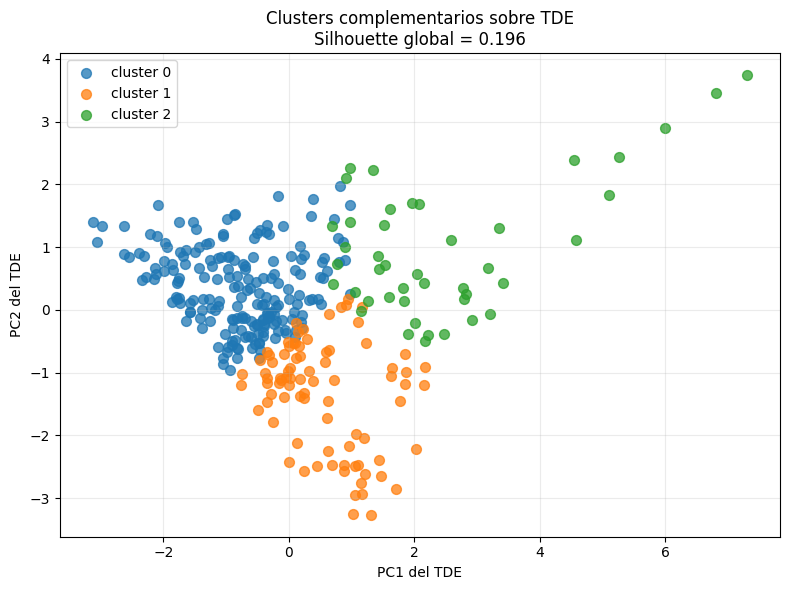

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=30)
emb['cluster_tde'] = kmeans.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, emb['cluster_tde']) if emb['cluster_tde'].nunique() > 1 else np.nan

cluster_summary = emb.groupby('cluster_tde').agg(
    n=('id','count'),
    ids_n=('id','nunique'),
    consume_rate=('consume','mean'),
    rechaza_rate=('rechaza','mean'),
    prueba_rate=('prueba','mean'),
    delta_valence_media=('delta_valence_ventana','mean'),
    delta_arousal_media=('delta_arousal_ventana','mean'),
    pc1_media=('PC1','mean'),
    pc2_media=('PC2','mean')
).reset_index()
cluster_summary['silhouette_global'] = sil
cluster_summary.round(3).to_csv(OUTPUT_DIR / '05_tde_cluster_summary.csv', index=False)
display(cluster_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
for cluster, sub in emb.groupby('cluster_tde'):
    ax.scatter(sub['PC1'], sub['PC2'], s=50, alpha=0.75, label=f'cluster {cluster}')
ax.set_xlabel('PC1 del TDE')
ax.set_ylabel('PC2 del TDE')
ax.set_title(f'Clusters complementarios sobre TDE\nSilhouette global = {sil:0.3f}')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_tde_clusters_pca.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Sensibilidad de parámetros TDE

Se compara el número de puntos disponibles para varias combinaciones de dimensión `m` y retardo `tau`. Esto ayuda a justificar el uso de `m=3`, `tau=1`: conserva suficiente muestra y captura memoria temporal corta.

,m,tau,puntos_tde,ids_representados,dimension_embedding
0,2,1,346,20,4
1,2,2,326,20,4
2,3,1,326,20,6
3,3,2,286,20,6
4,4,1,306,20,8
5,4,2,246,19,8


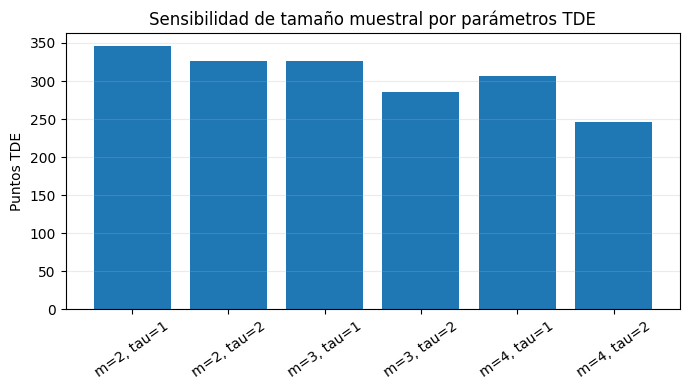

In [10]:
sensitivity_rows = []
for m in [2, 3, 4]:
    for tau in [1, 2]:
        tmp = build_delay_embedding(df, signal_cols, m=m, tau=tau)
        sensitivity_rows.append({
            'm': m,
            'tau': tau,
            'puntos_tde': len(tmp),
            'ids_representados': tmp['id'].nunique() if len(tmp) else 0,
            'dimension_embedding': m * len(signal_cols),
        })
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(OUTPUT_DIR / '05_sensibilidad_parametros_tde.csv', index=False)
display(sensitivity)

fig, ax = plt.subplots(figsize=(7, 4))
labels = [f"m={r.m}, tau={r.tau}" for r in sensitivity.itertuples()]
ax.bar(labels, sensitivity['puntos_tde'])
ax.set_ylabel('Puntos TDE')
ax.set_title('Sensibilidad de tamaño muestral por parámetros TDE')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_sensibilidad_parametros_tde.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Hallazgos documentados

La lectura siguiente resume los resultados del pipeline TDE + Mapper en lenguaje de reporte.

In [11]:
findings = []
findings.append('# Hallazgos TDE + Mapper — BabyFaceValidation\n')
findings.append(f'- Se construyeron {len(emb)} puntos de Time Delay Embedding con m={M}, tau={TAU}, usando `valence_final` y `arousal_final`.')
findings.append(f'- El embedding tiene {len(feature_cols)} dimensiones: tres estados consecutivos de valencia/arousal por punto.')
findings.append(f'- La proyección PCA del TDE explica {pca_summary.loc[1, "varianza_acumulada"]:.1%} de la varianza en sus dos primeros componentes.')
findings.append(f'- El grafo Mapper produjo {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas y {nx.number_connected_components(G) if G.number_of_nodes() else 0} componente(s) conectada(s).')
if not interpretation_summary.empty:
    dominant = interpretation_summary.iloc[0]
    findings.append(f'- La región dinámica con mayor peso fue `{dominant["interpretacion"]}`, con {int(dominant["n_total"])} puntos TDE agregados en sus nodos.')
findings.append('- La lectura topológica se interpreta como estructura descriptiva: no predice diagnóstico, sino que organiza trayectorias afectivas por similitud dinámica.')
findings.append('- Las conclusiones deben leerse con cautela por `FIT_FAILED`, faltantes en algunas etapas y diferente número de exposiciones por infante.')
findings.append('- La elección m=3, tau=1 es pragmática: captura memoria temporal corta sin perder demasiados casos. Parámetros más grandes reducen el número de ventanas disponibles.')

text = '\n'.join(findings)
(OUTPUT_DIR / '05_hallazgos_tde_mapper.md').write_text(text, encoding='utf-8')
display(Markdown(text))

# Hallazgos TDE + Mapper — BabyFaceValidation

- Se construyeron 326 puntos de Time Delay Embedding con m=3, tau=1, usando `valence_final` y `arousal_final`.
- El embedding tiene 6 dimensiones: tres estados consecutivos de valencia/arousal por punto.
- La proyección PCA del TDE explica 57.2% de la varianza en sus dos primeros componentes.
- El grafo Mapper produjo 12 nodos, 10 aristas y 2 componente(s) conectada(s).
- La región dinámica con mayor peso fue `zona intermedia / exploración`, con 335 puntos TDE agregados en sus nodos.
- La lectura topológica se interpreta como estructura descriptiva: no predice diagnóstico, sino que organiza trayectorias afectivas por similitud dinámica.
- Las conclusiones deben leerse con cautela por `FIT_FAILED`, faltantes en algunas etapas y diferente número de exposiciones por infante.
- La elección m=3, tau=1 es pragmática: captura memoria temporal corta sin perder demasiados casos. Parámetros más grandes reducen el número de ventanas disponibles.